In [1]:
# ==========================================================
# ResNet50 Model Development
# ----------------------------------------------------------
# Purpose:
# Develop a ResNet50-based deep-learning model for automated
# HEp-2 staining-pattern classification.
#
# Objective Connection:
# Objective 1: Develop a deep-learning model for automated
# HEp-2 pattern recognition.
# ==========================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import models

print("PyTorch version:", torch.__version__)
print("Torchvision imported successfully.")

PyTorch version: 2.13.0+cpu
Torchvision imported successfully.


In [2]:
# ==========================================================
# Load HEp-2 Dataset Configuration
# ----------------------------------------------------------
# Purpose:
# Recreate the dataset configuration required for ResNet50
# training using the preprocessing performed previously.
# ==========================================================

import os
import pandas as pd
import numpy as np

from PIL import Image
from sklearn.model_selection import train_test_split

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

data_dir = os.path.join("hep2_data", "data")

class_names = sorted([
    folder
    for folder in os.listdir(data_dir)
    if os.path.isdir(os.path.join(data_dir, folder))
])

print("Classes:", class_names)

Classes: ['Centromere', 'Golgi', 'Homogeneous', 'NuMem', 'Nucleolar', 'Speckled']


In [3]:
# ==========================================================
# Recreate Train / Validation / Test Split
# ----------------------------------------------------------
# Purpose:
# Recreate the same 70/15/15 stratified split used during
# preprocessing.
#
# Why?
# ResNet50 and DenseNet121 must use identical data splits
# so their performance can be compared fairly.
# ==========================================================

# Create image metadata
image_records = []

for class_name in class_names:

    class_path = os.path.join(data_dir, class_name)

    for file_name in os.listdir(class_path):

        if file_name.lower().endswith((".png", ".jpg", ".jpeg")):

            image_records.append({
                "image_path": os.path.join(class_path, file_name),
                "label": class_name
            })

df = pd.DataFrame(image_records)

# Recreate the exact same stratified split
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

print("Dataset split recreated successfully.\n")
print("Training:", len(train_df))
print("Validation:", len(val_df))
print("Testing:", len(test_df))

Dataset split recreated successfully.

Training: 9517
Validation: 2039
Testing: 2040


In [4]:
# ==========================================================
# Define Image Transformations
# ----------------------------------------------------------
# Purpose:
# Apply the same preprocessing pipeline used for the
# ResNet50 training, validation, and testing images.
#
# Training:
# - Resize to 224 × 224
# - Convert grayscale to 3-channel RGB
# - Apply data augmentation
# - Normalize using ImageNet statistics
#
# Validation / Testing:
# - Resize
# - Convert to 3-channel RGB
# - Normalize
#
# Why?
# Using identical preprocessing ensures that model
# evaluation remains consistent and reproducible.
# ==========================================================

IMAGE_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Transformations defined successfully.")

Transformations defined successfully.


In [5]:
# ==========================================================
# Create PyTorch Dataset
# ----------------------------------------------------------
# Purpose:
# Create a custom Dataset that loads each HEp-2 image and
# converts its class label into a numerical value.
#
# Why?
# ResNet50 requires image tensors and numerical class labels
# as inputs during training.
# ==========================================================

label_to_index = {
    class_name: index
    for index, class_name in enumerate(class_names)
}

index_to_label = {
    index: class_name
    for class_name, index in label_to_index.items()
}


class HEP2Dataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):

        image_path = self.dataframe.loc[index, "image_path"]
        label_name = self.dataframe.loc[index, "label"]

        image = Image.open(image_path).convert("L")
        image = image.convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = label_to_index[label_name]

        return image, label


print("Label mapping:")
for index, class_name in index_to_label.items():
    print(f"{index}: {class_name}")

print("\nPyTorch Dataset created successfully.")

Label mapping:
0: Centromere
1: Golgi
2: Homogeneous
3: NuMem
4: Nucleolar
5: Speckled

PyTorch Dataset created successfully.


In [6]:
# ==========================================================
# Create Dataset Objects and DataLoaders
# ----------------------------------------------------------
# Purpose:
# Create separate data pipelines for training, validation,
# and testing.
#
# Why?
# The same data pipeline will later be used for both ResNet50
# and DenseNet121 so their results can be compared fairly.
# ==========================================================

train_dataset = HEP2Dataset(
    train_df,
    transform=train_transform
)

val_dataset = HEP2Dataset(
    val_df,
    transform=val_test_transform
)

test_dataset = HEP2Dataset(
    test_df,
    transform=val_test_transform
)

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("DataLoaders created successfully.\n")
print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Testing samples:", len(test_dataset))
print("Batch size:", BATCH_SIZE)

DataLoaders created successfully.

Training samples: 9517
Validation samples: 2039
Testing samples: 2040
Batch size: 32


In [7]:
# ==========================================================
# Verify DataLoader Output
# ----------------------------------------------------------
# Purpose:
# Verify that the images and labels are loaded correctly
# before beginning model training.
#
# Expected input:
# 32 images × 3 channels × 224 × 224 pixels
# ==========================================================

images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Image data type:", images.dtype)
print("Label data type:", labels.dtype)
print("Label values in batch:", labels.unique().tolist())

Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
Image data type: torch.float32
Label data type: torch.int64
Label values in batch: [0, 1, 2, 3, 4, 5]


In [8]:
# ==========================================================
# Build ResNet50 Model
# ----------------------------------------------------------
# Purpose:
# Use a pretrained ResNet50 architecture for HEp-2
# staining-pattern classification.
#
# Why?
# Transfer learning allows the model to use features learned
# from a large image dataset and adapt them to the six
# HEp-2 pattern classes.
#
# Objective Connection:
# Objective 1: Automated HEp-2 pattern recognition.
# ==========================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

# Load pretrained ResNet50
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# Replace the final classification layer
num_features = model.fc.in_features

model.fc = nn.Linear(
    num_features,
    len(class_names)
)

model = model.to(device)

print("\nResNet50 model created successfully.")
print("Number of output classes:", len(class_names))
print("Classes:", class_names)

Device: cpu
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\Sinchana Raj/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:15<00:00, 6.64MB/s]



ResNet50 model created successfully.
Number of output classes: 6
Classes: ['Centromere', 'Golgi', 'Homogeneous', 'NuMem', 'Nucleolar', 'Speckled']


In [9]:
# ==========================================================
# Configure Loss Function and Optimizer
# ----------------------------------------------------------
# Purpose:
# Define the loss function and optimization strategy used
# to train the ResNet50 model.
#
# Loss Function:
# Cross-Entropy Loss for six-class classification.
#
# Optimizer:
# Adam optimizer for updating the model parameters.
#
# Objective Connection:
# Supports Objective 1 by enabling the ResNet50 model to
# learn HEp-2 staining-pattern classification.
# ==========================================================

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

print("Loss function:", criterion)
print("Optimizer:", optimizer.__class__.__name__)
print("Learning rate:", 1e-4)
print("Weight decay:", 1e-4)

Loss function: CrossEntropyLoss()
Optimizer: Adam
Learning rate: 0.0001
Weight decay: 0.0001


In [11]:
# ==========================================================
# ResNet50 Model Training
# ----------------------------------------------------------
# Purpose:
# Train ResNet50 for six-class HEp-2 pattern classification.
#
# Progress:
# - Displays batch-level progress during training
# - Displays epoch-level training and validation metrics
# - Saves the best model based on validation loss
#
# Objective Connection:
# Objective 1: Automated HEp-2 pattern recognition.
# ==========================================================

import copy
import time

NUM_EPOCHS = 10

best_val_loss = float("inf")
best_model_state = copy.deepcopy(model.state_dict())

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

print("==========================================================")
print("TRAINING STARTED")
print("==========================================================")
print("Device:", device)
print("Epochs:", NUM_EPOCHS)
print()

for epoch in range(NUM_EPOCHS):

    epoch_start = time.time()

    # ------------------------------------------------------
    # Training phase
    # ------------------------------------------------------

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    total_batches = len(train_loader)

    for batch_idx, (images, labels) in enumerate(train_loader):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predictions = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predictions == labels).sum().item()

        # --------------------------------------------------
        # Live batch progress
        # --------------------------------------------------

        if batch_idx % 20 == 0:
            print(
                f"[Epoch {epoch + 1}] "
                f"Batch {batch_idx}/{total_batches} | "
                f"Loss: {loss.item():.4f}"
            )

    epoch_train_loss = running_loss / total
    epoch_train_accuracy = correct / total

    # ------------------------------------------------------
    # Validation phase
    # ------------------------------------------------------

    model.eval()

    running_val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item() * images.size(0)

            _, predictions = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predictions == labels).sum().item()

    epoch_val_loss = running_val_loss / total
    epoch_val_accuracy = correct / total

    # ------------------------------------------------------
    # Store metrics
    # ------------------------------------------------------

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)

    train_accuracies.append(epoch_train_accuracy)
    val_accuracies.append(epoch_val_accuracy)

    # ------------------------------------------------------
    # Save best model
    # ------------------------------------------------------

    if epoch_val_loss < best_val_loss:

        best_val_loss = epoch_val_loss
        best_model_state = copy.deepcopy(model.state_dict())

        torch.save(
            best_model_state,
            "resnet50_best.pth"
        )

        best_marker = " <-- BEST MODEL SAVED"

    else:
        best_marker = ""

    epoch_time = (time.time() - epoch_start) / 60

    print()
    print(
        f"Epoch [{epoch + 1}/{NUM_EPOCHS}] | "
        f"Train Loss: {epoch_train_loss:.4f} | "
        f"Train Acc: {epoch_train_accuracy:.4f} | "
        f"Val Loss: {epoch_val_loss:.4f} | "
        f"Val Acc: {epoch_val_accuracy:.4f} | "
        f"Time: {epoch_time:.1f} min"
        f"{best_marker}"
    )
    print("-" * 70)

# ----------------------------------------------------------
# Load the best model
# ----------------------------------------------------------

model.load_state_dict(best_model_state)

print()
print("==========================================================")
print("TRAINING COMPLETED")
print("==========================================================")
print("Best validation loss:", best_val_loss)
print("Best model saved as: resnet50_best.pth")

TRAINING STARTED
Device: cpu
Epochs: 10

[Epoch 1] Batch 0/298 | Loss: 0.5005
[Epoch 1] Batch 20/298 | Loss: 0.3536
[Epoch 1] Batch 40/298 | Loss: 0.5684
[Epoch 1] Batch 60/298 | Loss: 0.2111
[Epoch 1] Batch 80/298 | Loss: 0.3552
[Epoch 1] Batch 100/298 | Loss: 0.6255
[Epoch 1] Batch 120/298 | Loss: 0.1561
[Epoch 1] Batch 140/298 | Loss: 0.4555
[Epoch 1] Batch 160/298 | Loss: 0.1821
[Epoch 1] Batch 180/298 | Loss: 0.2386
[Epoch 1] Batch 200/298 | Loss: 0.2158
[Epoch 1] Batch 220/298 | Loss: 0.2018
[Epoch 1] Batch 240/298 | Loss: 0.2092
[Epoch 1] Batch 260/298 | Loss: 0.4004
[Epoch 1] Batch 280/298 | Loss: 0.1664

Epoch [1/10] | Train Loss: 0.3409 | Train Acc: 0.8814 | Val Loss: 0.2005 | Val Acc: 0.9358 | Time: 61.9 min <-- BEST MODEL SAVED
----------------------------------------------------------------------
[Epoch 2] Batch 0/298 | Loss: 0.3251
[Epoch 2] Batch 20/298 | Loss: 0.2550
[Epoch 2] Batch 40/298 | Loss: 0.3291
[Epoch 2] Batch 60/298 | Loss: 0.0700
[Epoch 2] Batch 80/298 | Los

In [12]:
# ==========================================================
# ResNet50 Test Evaluation
# ----------------------------------------------------------
# Purpose:
# Evaluate the BEST ResNet50 model on the completely unseen
# test set.
#
# This gives the final unbiased performance of the model.
# ==========================================================

import torch
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Load the best saved model
best_model_path = "resnet50_best.pth"

model.load_state_dict(torch.load(
    best_model_path,
    map_location=device
))

model = model.to(device)
model.eval()

all_predictions = []
all_labels = []

test_loss = 0.0
correct = 0
total = 0

criterion = torch.nn.CrossEntropyLoss()

print("=" * 60)
print("RESNET50 TEST EVALUATION")
print("=" * 60)

with torch.no_grad():

    for batch_idx, (images, labels) in enumerate(test_loader):

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels)

        test_loss += loss.item() * images.size(0)

        _, predictions = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predictions == labels).sum().item()

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        if batch_idx % 20 == 0:
            print(
                f"Test Batch {batch_idx}/{len(test_loader)}"
            )

# Calculate metrics
test_loss = test_loss / total
test_accuracy = correct / total

precision = precision_score(
    all_labels,
    all_predictions,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    all_labels,
    all_predictions,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    all_labels,
    all_predictions,
    average="weighted",
    zero_division=0
)

print("\n" + "=" * 60)
print("FINAL RESNET50 TEST RESULTS")
print("=" * 60)

print(f"Test Loss      : {test_loss:.4f}")
print(f"Test Accuracy  : {test_accuracy:.4f}")
print(f"Test Accuracy  : {test_accuracy * 100:.2f}%")
print(f"Precision      : {precision:.4f}")
print(f"Recall         : {recall:.4f}")
print(f"F1 Score       : {f1:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=class_names,
        zero_division=0
    )
)

RESNET50 TEST EVALUATION
Test Batch 0/64
Test Batch 20/64
Test Batch 40/64
Test Batch 60/64

FINAL RESNET50 TEST RESULTS
Test Loss      : 0.0983
Test Accuracy  : 0.9696
Test Accuracy  : 96.96%
Precision      : 0.9699
Recall         : 0.9696
F1 Score       : 0.9697

Classification Report:
              precision    recall  f1-score   support

  Centromere       0.99      0.98      0.98       411
       Golgi       0.95      0.96      0.95       108
 Homogeneous       0.94      0.98      0.96       374
       NuMem       0.99      0.98      0.98       332
   Nucleolar       0.97      0.97      0.97       390
    Speckled       0.96      0.95      0.96       425

    accuracy                           0.97      2040
   macro avg       0.97      0.97      0.97      2040
weighted avg       0.97      0.97      0.97      2040



<Figure size 900x700 with 0 Axes>

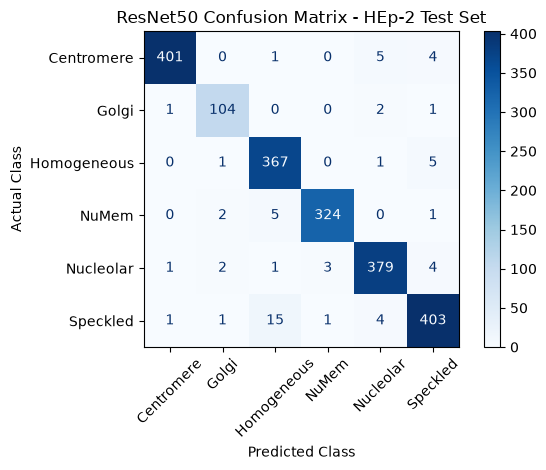

In [13]:
# ==========================================================
# ResNet50 Confusion Matrix
# ----------------------------------------------------------
# Purpose:
# Visualize class-wise prediction performance and identify
# which HEp-2 staining patterns are being confused.
# ==========================================================

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate confusion matrix
cm = confusion_matrix(
    all_labels,
    all_predictions
)

# Plot
plt.figure(figsize=(9, 7))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    cmap="Blues",
    values_format="d"
)

plt.title("ResNet50 Confusion Matrix - HEp-2 Test Set")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()